In [29]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

In [30]:
sdss_data = pd.read_csv("../input/tables/DATA7901_DR19.csv")

print(sdss_data.head())

                 objid          ra       dec    Column1   Column2           l  \
0  1237651735759683629  186.146081  1.892348  186.14609  1.892344  287.498605   
1  1237671266571256001  191.129031  1.910968  191.12904  1.910973  298.877935   
2  1237651735766237377  201.190144  1.913935  201.19014  1.913923  321.904433   
3  1237674601603334272  207.863421  1.711688  207.86342  1.711728  334.960413   
4  1237674602677534911  209.309883  1.721420  209.30985  1.721405  337.527142   

           b           specObjID  plate    mjd  ...  nvote_mr1 nvote_mr2  \
0  63.956436  584369852622333952    519  52283  ...        0.0       0.0   
1  64.728146  587795651631278080    522  52024  ...        0.0       0.0   
2  63.551451  593421308209948672    527  52342  ...        0.0       0.0   
3  60.795423  596749249727719424    530  52026  ...        0.0       0.0   
4  60.096803  597917755743692800    531  52028  ...        0.0       0.0   

  nvote_mon   p_el   p_cw  p_acw  p_edge   p_dk   p_mg  

In [31]:
# Galaxy Zoo vote columns and fractions used below
# nvote_* (vote counts):
# - nvote_tot: Total votes
# - nvote_std: Total votes for the standard classification
# - nvote_mr1: Total votes for the vertical mirrored classification
# - nvote_mr2: Total votes for the diagonally mirrored classification
# - nvote_mon: Total votes for the monochrome classification
# p_* (vote fractions in [0,1]):
# - p_el (float): Fraction of votes for elliptical
# - p_cw: Fraction of votes for clockwise spiral
# - p_acw: Fraction of votes for anticlockwise spiral
# - p_edge: Fraction of votes for edge-on disk
# - p_dk: Fraction of votes for don't know
# - p_mg: Fraction of votes for merger
# - p_cs: Fraction of votes for combined spiral (cw + acw + edge-on)

# Validate all `p_` and all `nvote_` parameters for galaxies and report completeness/validity

# Focus on galaxies only
galaxy_rows = sdss_data[sdss_data['class'] == 'GALAXY'].copy()

# Identify columns
p_cols = [c for c in galaxy_rows.columns if c.startswith('p_')]
nvote_cols = [c for c in galaxy_rows.columns if c.startswith('nvote_')]

# Coerce to numeric for all target columns
if p_cols:
    galaxy_rows[p_cols] = galaxy_rows[p_cols].apply(pd.to_numeric, errors='coerce')
if nvote_cols:
    galaxy_rows[nvote_cols] = galaxy_rows[nvote_cols].apply(pd.to_numeric, errors='coerce')

total_galaxies = len(galaxy_rows)
print(f"Total galaxies: {total_galaxies}")

# Validate p_* columns: values in [0,1]
for col in p_cols:
    missing = galaxy_rows[col].isna().sum()
    out_of_range = ((galaxy_rows[col] < 0.0) | (galaxy_rows[col] > 1.0)) & galaxy_rows[col].notna()
    print(f"{col} - missing: {missing} ({missing/total_galaxies:.2%}), out of [0,1]: {int(out_of_range.sum())}")

# Validate nvote_* columns: non-negative integers
for col in nvote_cols:
    missing = galaxy_rows[col].isna().sum()
    negative = ((galaxy_rows[col] < 0) & galaxy_rows[col].notna()).sum()
    non_integer = ((galaxy_rows[col].notna()) & ((galaxy_rows[col] % 1) != 0)).sum()
    print(f"{col} - missing: {missing} ({missing/total_galaxies:.2%}), negative: {int(negative)}, non-integer: {int(non_integer)}")


Total galaxies: 503904
p_el - missing: 24769 (4.92%), out of [0,1]: 0
p_cw - missing: 24769 (4.92%), out of [0,1]: 0
p_acw - missing: 24769 (4.92%), out of [0,1]: 0
p_edge - missing: 24769 (4.92%), out of [0,1]: 0
p_dk - missing: 24769 (4.92%), out of [0,1]: 0
p_mg - missing: 24769 (4.92%), out of [0,1]: 0
p_cs - missing: 24769 (4.92%), out of [0,1]: 0
nvote_tot - missing: 24769 (4.92%), negative: 0, non-integer: 0
nvote_std - missing: 24769 (4.92%), negative: 0, non-integer: 0
nvote_mr1 - missing: 24769 (4.92%), negative: 0, non-integer: 0
nvote_mr2 - missing: 24769 (4.92%), negative: 0, non-integer: 0
nvote_mon - missing: 24769 (4.92%), negative: 0, non-integer: 0


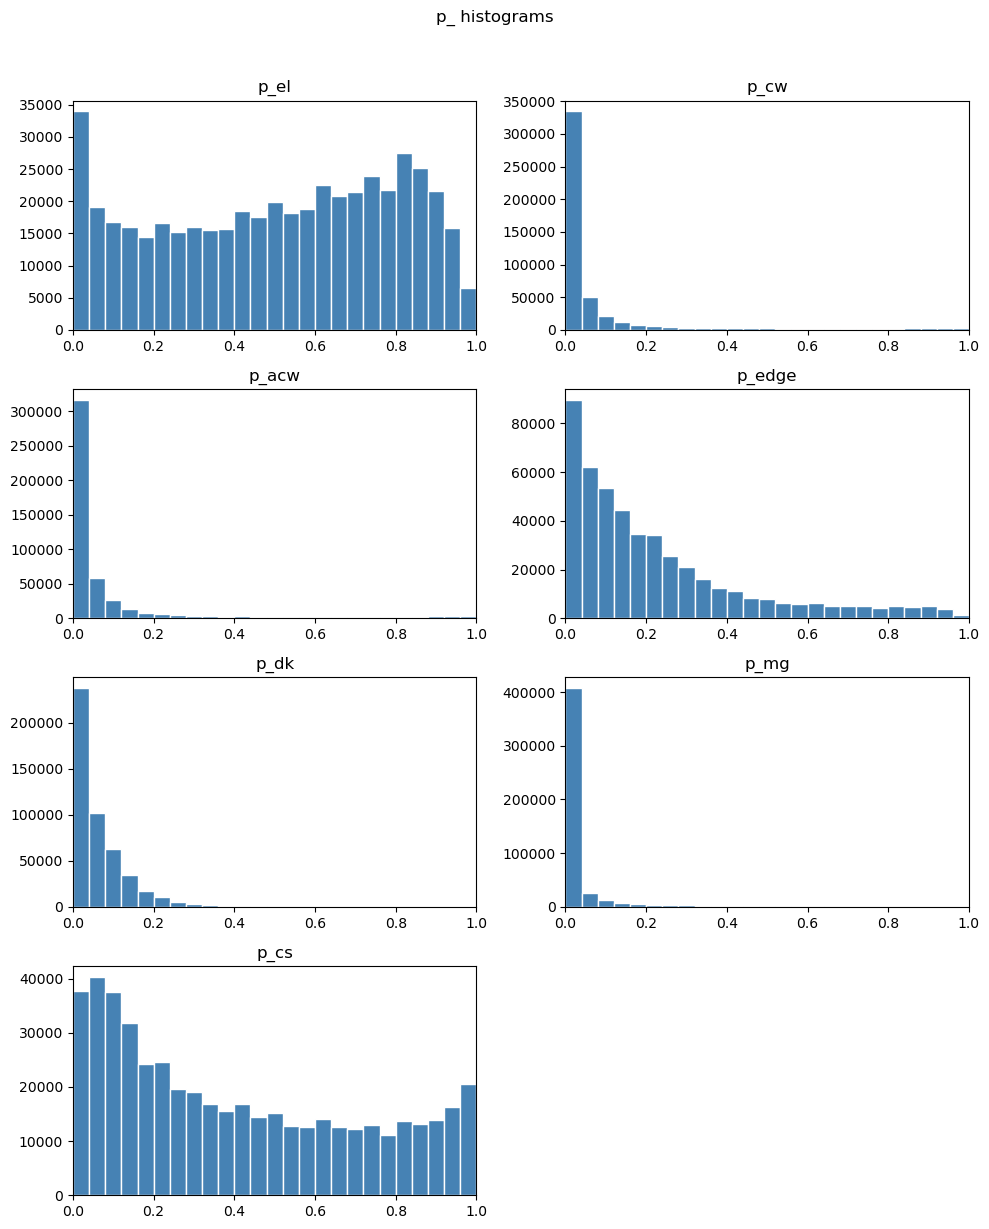

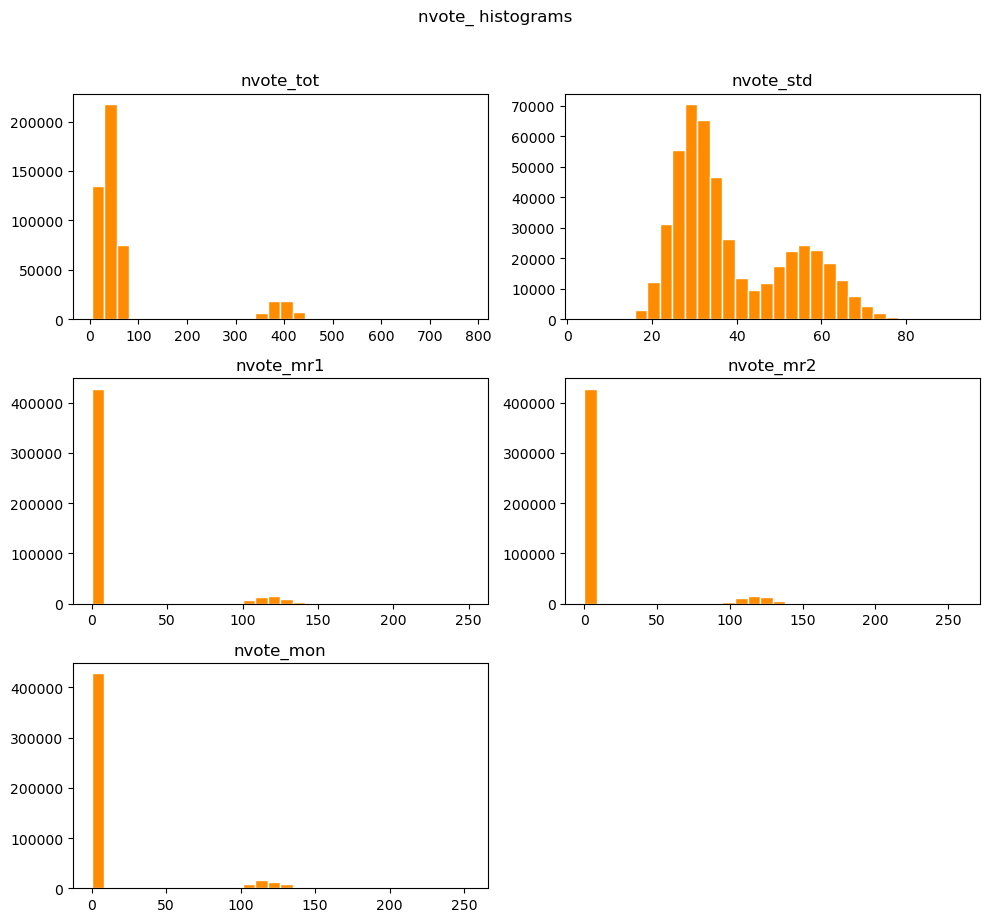

In [28]:
# Histograms for all `p_` and `nvote_` columns (galaxies only), two per row

p_cols = [c for c in galaxy_rows.columns if c.startswith('p_')]
nvote_cols = [c for c in galaxy_rows.columns if c.startswith('nvote_')]

# Helper to plot a list of columns in a 2-per-row grid
def plot_cols_two_per_row(cols, process_fn, title, color):
    if not cols:
        print(f"No columns to plot for {title}.")
        return
    n = len(cols)
    rows = math.ceil(n / 2)
    fig, axes = plt.subplots(rows, 2, figsize=(10, 3.0*rows), squeeze=False)
    axes_flat = axes.ravel()
    for i, col in enumerate(cols):
        ax = axes_flat[i]
        vals = process_fn(galaxy_rows[col].dropna())
        ax.hist(vals, bins=25 if title.startswith('p_') else 30, color=color, edgecolor='white')
        ax.set_title(col)
        if title.startswith('p_'):
            ax.set_xlim(0, 1)
    # hide any extra axes
    for j in range(len(cols), len(axes_flat)):
        axes_flat[j].axis('off')
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

# Define processors
p_process = lambda s: s[(s >= 0.0) & (s <= 1.0)]
nvote_process = lambda s: s[s >= 0]

plot_cols_two_per_row(p_cols, p_process, title='p_ histograms', color='steelblue')
plot_cols_two_per_row(nvote_cols, nvote_process, title='nvote_ histograms', color='darkorange')


In [12]:
# Prepare and (optionally) download Legacy Survey cutouts for valid galaxies

# Build mask of valid galaxies
valid_mask = (
    galaxy_rows['p_el'].between(0.0, 1.0)
    & galaxy_rows['nvote_tot'].notna()
    & (galaxy_rows['nvote_tot'] >= 0)
    & ((galaxy_rows['nvote_tot'] % 1) == 0)
    & galaxy_rows['ra'].notna()
    & galaxy_rows['dec'].notna()
    & galaxy_rows['objid'].notna()
)

valid_galaxies = galaxy_rows.loc[valid_mask].copy()

# Prepare identifiers and coordinates
# Use `objid` as the filename-friendly target id
targetid = valid_galaxies['objid'].astype('Int64').astype(str).values
ra = valid_galaxies['ra'].astype(float).values
dec = valid_galaxies['dec'].astype(float).values

# Ensure output directory exists
os.makedirs("../input/images", exist_ok=True)

# Limit downloads for now
num_to_download = 10  # set to 10 later to fetch the first 10
max_first = 10
n = min(num_to_download, max_first, len(targetid))

print(f"Valid galaxies available: {len(targetid)}. Planned downloads (first {max_first}): {n}")

for i in range(n):
    cmd = (
        "wget -P . -O "
        + "../input/images/" + str(targetid[i]) + ".jpeg "
        + "https://www.legacysurvey.org/viewer/jpeg-cutout?ra=" + str(ra[i])
        + "\\&dec=" + str(dec[i])
        + "\\&layer=ls-dr9\\&pixscale=0.1\\&bands=grz"
    )
    print(cmd)
    os.system(cmd)

if n == 0:
    print("Download limit is 0. No files downloaded. Increase `num_to_download` to proceed.")


Valid galaxies available: 479132. Planned downloads (first 10): 10
wget -P . -O ../input/images/1237650795683184714.jpeg https://www.legacysurvey.org/viewer/jpeg-cutout?ra=146.222253348606\&dec=-0.375901187288793\&layer=ls-dr9\&pixscale=0.1\&bands=grz


--2025-08-14 17:12:14--  https://www.legacysurvey.org/viewer/jpeg-cutout?ra=146.222253348606&dec=-0.375901187288793&layer=ls-dr9&pixscale=0.1&bands=grz
Resolving www.legacysurvey.org (www.legacysurvey.org)... 128.55.206.111, 128.55.206.107, 128.55.206.110, ...
Connecting to www.legacysurvey.org (www.legacysurvey.org)|128.55.206.111|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18922 (18K) [image/jpeg]
Saving to: ‘../input/images/1237650795683184714.jpeg’

     0K .......... ........                                   100%  112K=0.2s

2025-08-14 17:12:16 (112 KB/s) - ‘../input/images/1237650795683184714.jpeg’ saved [18922/18922]

--2025-08-14 17:12:16--  https://www.legacysurvey.org/viewer/jpeg-cutout?ra=145.647881555174&dec=-0.77172514962061&layer=ls-dr9&pixscale=0.1&bands=grz
Resolving www.legacysurvey.org (www.legacysurvey.org)... 128.55.206.107, 128.55.206.110, 128.55.206.111, ...
Connecting to www.legacysurvey.org (www.legacysurvey.org)|128.55.206.107|:44

wget -P . -O ../input/images/1237650795146051733.jpeg https://www.legacysurvey.org/viewer/jpeg-cutout?ra=145.647881555174\&dec=-0.77172514962061\&layer=ls-dr9\&pixscale=0.1\&bands=grz


connected.
HTTP request sent, awaiting response... 200 OK
Length: 17200 (17K) [image/jpeg]
Saving to: ‘../input/images/1237650795146051733.jpeg’

     0K .......... ......                                     100%  102K=0.2s

2025-08-14 17:12:18 (102 KB/s) - ‘../input/images/1237650795146051733.jpeg’ saved [17200/17200]

--2025-08-14 17:12:18--  https://www.legacysurvey.org/viewer/jpeg-cutout?ra=145.850488780277&dec=1.20352840894456&layer=ls-dr9&pixscale=0.1&bands=grz
Resolving www.legacysurvey.org (www.legacysurvey.org)... 

wget -P . -O ../input/images/1237651752921661579.jpeg https://www.legacysurvey.org/viewer/jpeg-cutout?ra=145.850488780277\&dec=1.20352840894456\&layer=ls-dr9\&pixscale=0.1\&bands=grz


...

Resolving www.legacysurvey.org (www.legacysurvey.org)... 128.55.206.111, 128.55.206.113, 128.55.206.108, ...
Connecting to www.legacysurvey.org (www.legacysurvey.org)|128.55.206.111|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 25141 (25K) [image/jpeg]
Saving to: ‘../input/images/1237648721217716541.jpeg’

     0K .......... .......... ....                            100%  149K=0.2s

2025-08-14 17:12:26 (149 KB/s) - ‘../input/images/1237648721217716541.jpeg’ saved [25141/25141]

--2025-08-14 17:12:26--  https://www.legacysurvey.org/viewer/jpeg-cutout?ra=149.38287415486&dec=-0.252225751615964&layer=ls-dr9&pixscale=0.1&bands=grz
Resolving www.legacysurvey.org (www.legacysurvey.org)... 

wget -P . -O ../input/images/1237651800696946942.jpeg https://www.legacysurvey.org/viewer/jpeg-cutout?ra=149.38287415486\&dec=-0.252225751615964\&layer=ls-dr9\&pixscale=0.1\&bands=grz


128.55.206.111, 128.55.206.113, 128.55.206.108, ...
Connecting to www.legacysurvey.org (www.legacysurvey.org)|128.55.206.111|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21351 (21K) [image/jpeg]
Saving to: ‘../input/images/1237651800696946942.jpeg’

     0K .......... ..........                                 100%  126K=0.2s

2025-08-14 17:12:27 (126 KB/s) - ‘../input/images/1237651800696946942.jpeg’ saved [21351/21351]

--2025-08-14 17:12:28--  https://www.legacysurvey.org/viewer/jpeg-cutout?ra=148.866650921465&dec=-1.09175621302181&layer=ls-dr9&pixscale=0.1&bands=grz


wget -P . -O ../input/images/1237651799623008574.jpeg https://www.legacysurvey.org/viewer/jpeg-cutout?ra=148.866650921465\&dec=-1.09175621302181\&layer=ls-dr9\&pixscale=0.1\&bands=grz


Resolving www.legacysurvey.org (www.legacysurvey.org)... 128.55.206.111, 128.55.206.113, 128.55.206.108, ...
Connecting to www.legacysurvey.org (www.legacysurvey.org)|128.55.206.111|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21869 (21K) [image/jpeg]
Saving to: ‘../input/images/1237651799623008574.jpeg’

     0K .......... .......... .                               100%  128K=0.2s

2025-08-14 17:12:29 (128 KB/s) - ‘../input/images/1237651799623008574.jpeg’ saved [21869/21869]



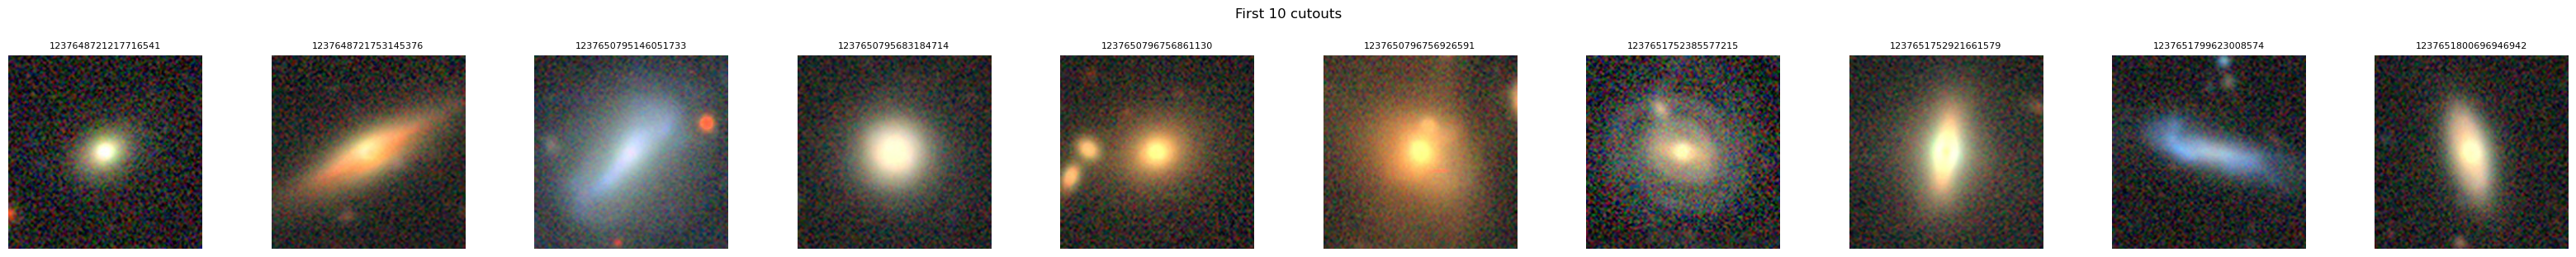

In [21]:
# Visualize the first 10 downloaded cutout images
from pathlib import Path

img_dir = Path("../input/images")
jpeg_files = sorted(img_dir.glob("*.jpeg"))

if len(jpeg_files) == 0:
    print("No images found in ../input/images.")
else:
    files = jpeg_files[:10]
    cols = len(files)
    fig, axes = plt.subplots(1, cols, figsize=(3*cols + 2, 3))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    for ax, f in zip(axes, files):
        img = plt.imread(str(f))
        ax.imshow(img)
        ax.set_title(f.stem, fontsize=8)
        ax.axis("off")
    plt.suptitle("First 10 cutouts", y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
# Download first 10 SDSS spectra (DR19) using wget
# Requires `valid_galaxies` from the earlier cell and columns: plate, mjd, fiberid
# Note: If you encounter 404 errors with the default base, try the alternate base
#       documented on the SDSS SAS index:
#       https://data.sdss.org/sas/dr19/spectro/sdss/redux/26/spectra/lite/

# Build mask requiring spectra identifiers
spec_mask = (
    valid_galaxies['plate'].notna()
    & valid_galaxies['mjd'].notna()
    & valid_galaxies['fiberid'].notna()
)

spec_rows = valid_galaxies.loc[spec_mask].copy()

# Cast and zero-pad
plate = spec_rows['plate'].astype('Int64').astype(str).str.zfill(4).values
mjd = spec_rows['mjd'].astype('Int64').astype(str).values
fiberid = spec_rows['fiberid'].astype('Int64').astype(str).str.zfill(4).values

# Ensure destination dir exists
os.makedirs("../input/spectra", exist_ok=True)

num_to_download = 10
max_first = 10
n_spec = min(num_to_download, max_first, len(plate))
print(f"Valid spectra rows available: {len(plate)}. Planned spectra downloads (first {max_first}): {n_spec}")

# Primary and alternate SAS bases. Some environments may require the alternate order
# ("spectro/sdss" instead of "sdss/spectro"). We'll try primary, then fallback to alternate.
base_primary = "https://data.sdss.org/sas/dr19/sdss/spectro/redux/26/spectra/lite/"
base_alternate = "https://data.sdss.org/sas/dr19/spectro/sdss/redux/26/spectra/lite/"

for i in range(n_spec):
    filename = f"spec-{plate[i]}-{mjd[i]}-{fiberid[i]}.fits"
    dest = f"../input/spectra/{filename}"

    # Skip if already downloaded
    if os.path.exists(dest):
        print(f"[{i+1}/{n_spec}] {filename} already exists -> skip")
        continue

    # Try primary
    url1 = base_primary + plate[i] + "/" + filename
    cmd1 = f"wget -q -O {dest} {url1}"
    rc1 = os.system(cmd1)

    if rc1 == 0 and os.path.exists(dest):
        print(f"[{i+1}/{n_spec}] {url1} -> ok")
        continue

    # Fallback to alternate on failure (e.g., 404)
    url2 = base_alternate + plate[i] + "/" + filename
    cmd2 = f"wget -q -O {dest} {url2}"
    rc2 = os.system(cmd2)

    if rc2 == 0 and os.path.exists(dest):
        print(f"[{i+1}/{n_spec}] {url1} -> fail({rc1}); retry {url2} -> ok")
    else:
        print(f"[{i+1}/{n_spec}] {url1} -> fail({rc1}); retry {url2} -> fail({rc2})")

if n_spec == 0:
    print("No spectra downloaded (n_spec == 0). Increase `num_to_download` if needed.")


Valid spectra rows available: 479132. Planned spectra downloads (first 10): 10
[1/10] https://data.sdss.org/sas/dr19/sdss/spectro/redux/26/spectra/lite/0266/spec-0266-51630-0168.fits -> fail(2048)
[2/10] https://data.sdss.org/sas/dr19/sdss/spectro/redux/26/spectra/lite/0266/spec-0266-51630-0215.fits -> fail(2048)
[3/10] https://data.sdss.org/sas/dr19/sdss/spectro/redux/26/spectra/lite/0266/spec-0266-51630-0367.fits -> fail(2048)
[4/10] https://data.sdss.org/sas/dr19/sdss/spectro/redux/26/spectra/lite/0266/spec-0266-51630-0481.fits -> fail(2048)
[5/10] https://data.sdss.org/sas/dr19/sdss/spectro/redux/26/spectra/lite/0266/spec-0266-51630-0486.fits -> fail(2048)
[6/10] https://data.sdss.org/sas/dr19/sdss/spectro/redux/26/spectra/lite/0266/spec-0266-51630-0598.fits -> fail(2048)
[7/10] https://data.sdss.org/sas/dr19/sdss/spectro/redux/26/spectra/lite/0267/spec-0267-51608-0413.fits -> fail(2048)
[8/10] https://data.sdss.org/sas/dr19/sdss/spectro/redux/26/spectra/lite/0268/spec-0268-51633-0

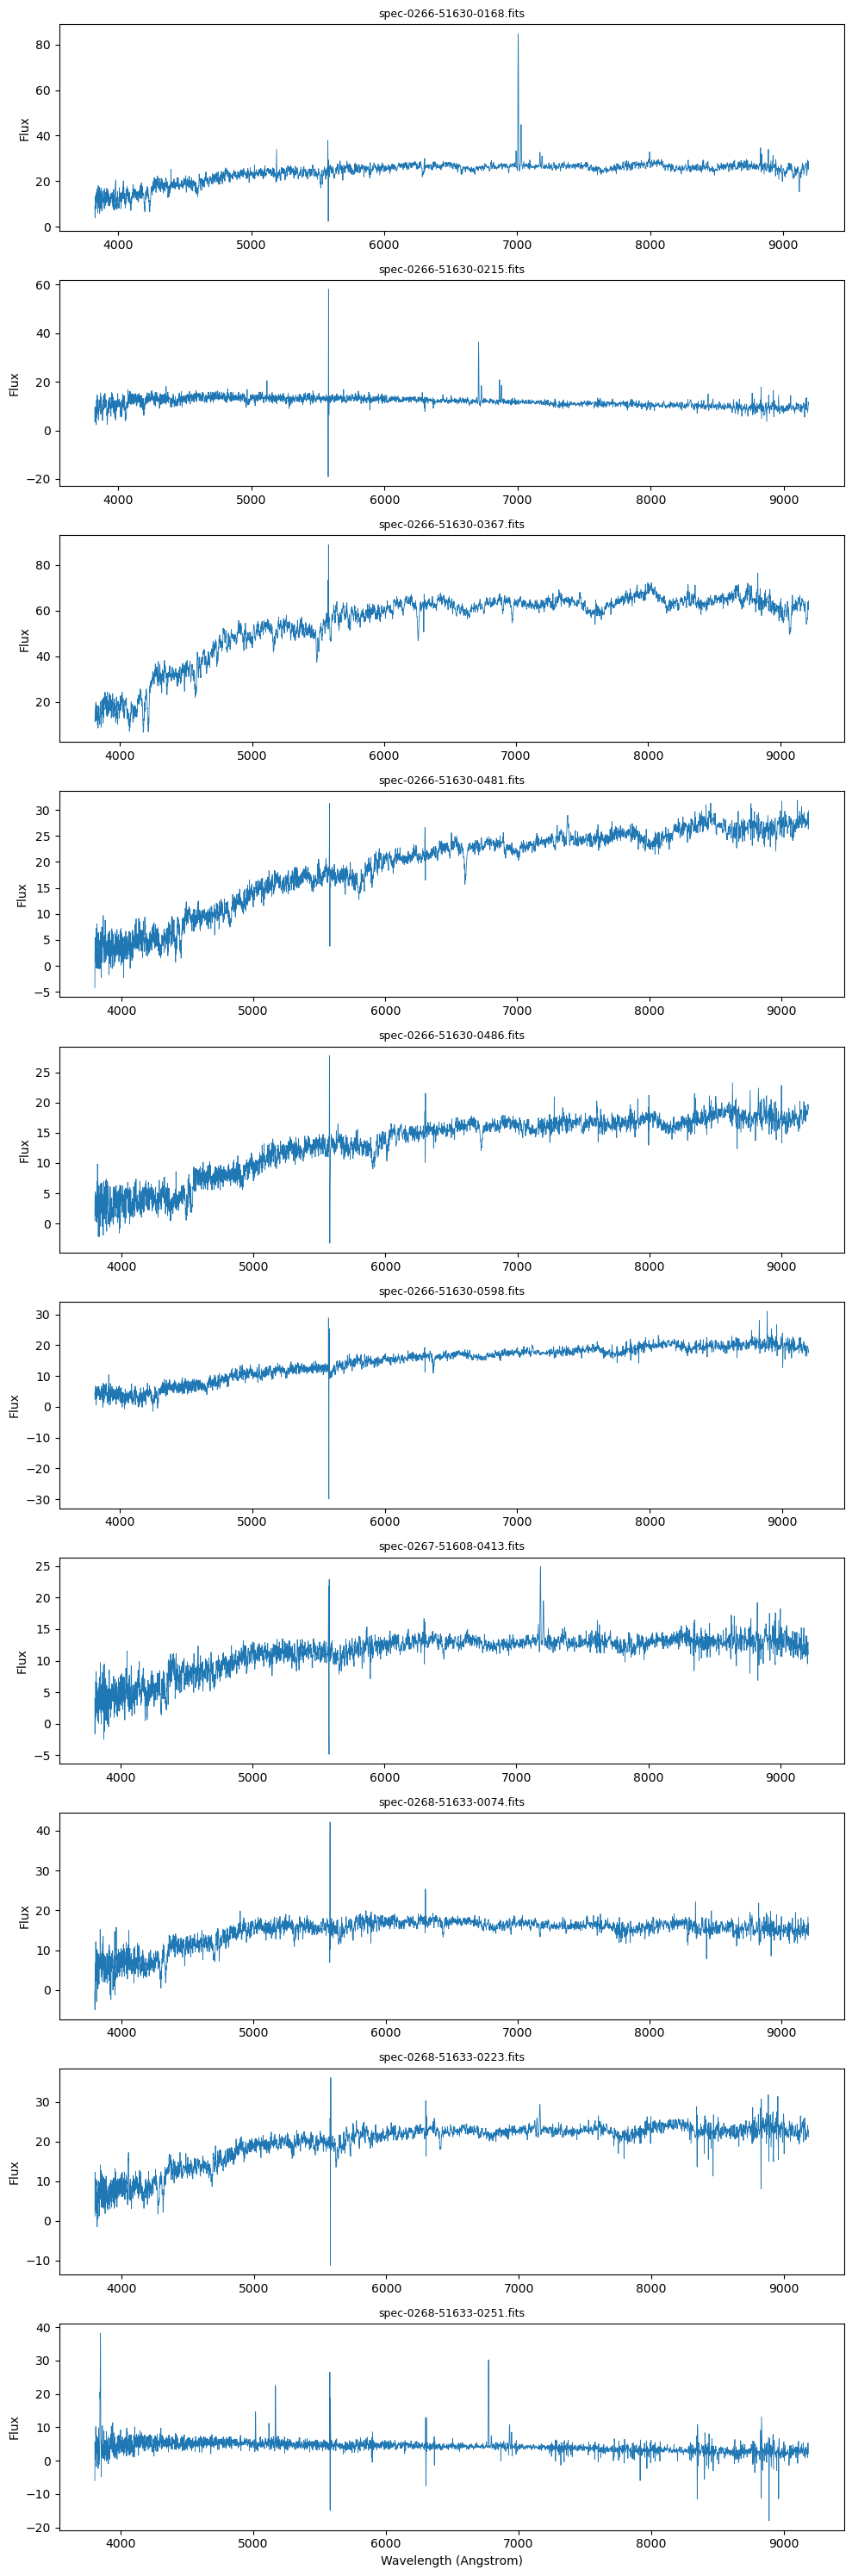

In [20]:
# Visualize a few downloaded spectra (reads FITS and plots flux vs wavelength)
try:
    from astropy.io import fits
except ImportError:
    raise ImportError("astropy is required for reading FITS. Install with `pip install astropy` and re-run this cell.")

spec_dir = Path("../input/spectra")
fit_files = sorted(spec_dir.glob("*.fits"))

def read_spectrum_fits(path: Path):
    with fits.open(str(path), memmap=False) as hdul:
        wavelength = None
        flux = None
        ivar = None
        # Try table HDUs with 'loglam'/'flux' columns
        for hdu in hdul:
            data = getattr(hdu, 'data', None)
            cols = []
            try:
                cols = [c.lower() for c in hdu.columns.names] if hasattr(hdu, 'columns') else []
            except Exception:
                cols = []
            if data is not None and cols:
                get = lambda name: data[name] if name in data.names else data[name.upper()]
                if ('loglam' in cols or 'LOGLAM' in getattr(hdu, 'columns', [])) and ('flux' in cols or 'FLUX' in getattr(hdu, 'columns', [])):
                    loglam = get('loglam') if 'loglam' in cols else get('LOGLAM')
                    flux = np.asarray(get('flux') if 'flux' in cols else get('FLUX'), dtype=float)
                    if 'ivar' in cols or 'IVAR' in getattr(hdu, 'columns', []):
                        ivar = np.asarray(get('ivar') if 'ivar' in cols else get('IVAR'), dtype=float)
                    wavelength = np.power(10.0, np.asarray(loglam, dtype=float))
                    break
        # Fallback: image HDU with COEFF0/COEFF1 and 1D flux
        if wavelength is None:
            for hdu in hdul:
                data = getattr(hdu, 'data', None)
                if isinstance(data, np.ndarray) and data.ndim == 1:
                    hdr = hdu.header
                    if 'COEFF0' in hdr and 'COEFF1' in hdr:
                        n = data.shape[0]
                        pix = np.arange(n, dtype=float)
                        wavelength = 10.0 ** (hdr['COEFF0'] + hdr['COEFF1'] * pix)
                        flux = data.astype(float)
                        ivar = None
                        break
        return wavelength, flux, ivar

if len(fit_files) == 0:
    print("No FITS spectra found in ../input/spectra.")
else:
    k = min(10, len(fit_files))
    files = fit_files[:k]
    fig, axes = plt.subplots(k, 1, figsize=(10, 3.0*k), sharex=False)
    if k == 1:
        axes = [axes]
    for ax, f in zip(axes, files):
        wave, flux, ivar = read_spectrum_fits(f)
        if wave is None or flux is None:
            ax.text(0.5, 0.5, f"Unable to read {f.name}", ha='center', va='center')
            ax.axis('off')
            continue
        mask = np.isfinite(wave) & np.isfinite(flux)
        wave = wave[mask]
        flux = flux[mask]
        ax.plot(wave, flux, lw=0.6)
        ax.set_ylabel('Flux')
        ax.set_title(f.name, fontsize=9)
    axes[-1].set_xlabel('Wavelength (Angstrom)')
    plt.tight_layout()
    plt.show()
